# Bank Customer Churn Prediction
**SkillInfyTech Data Science Internship — Project 1**

**Goal:** Predict which bank customers are likely to churn (leave) based on their historical behaviour.

**Dataset:** Kaggle Bank Customer Churn Prediction (~10,000 rows)

**Pipeline:**
1. Exploratory Data Analysis (EDA)
2. Preprocessing (encoding, scaling, SMOTE)
3. Model Training (Logistic Regression, Decision Tree, XGBoost)
4. Evaluation (Accuracy, F1, ROC-AUC, Confusion Matrix)
5. Explainability (SHAP)
6. Save model for deployment

## 0. Install & Import Libraries

In [1]:
# Run this cell once to install any missing packages
# !pip install xgboost shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully.')

All libraries imported successfully.


## 1. Load Data

In [3]:
df = pd.read_csv('../data/Churn_Modelling.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


## 2. Exploratory Data Analysis (EDA)

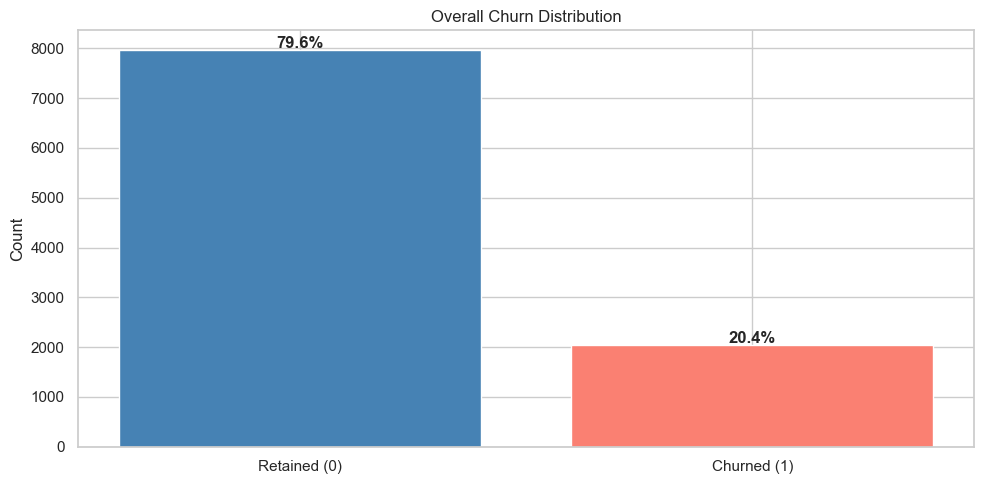

Churn rate: 20.37%


In [7]:
# --- 2.1 Overall Churn Rate ---
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
ax.bar(['Retained (0)', 'Churned (1)'], churn_counts, color=['steelblue', 'salmon'])
ax.set_title('Overall Churn Distribution')
ax.set_ylabel('Count')
for i, (count, pct) in enumerate(zip(churn_counts, churn_pct)):
    ax.text(i, count + 50, f'{pct:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Churn rate: {churn_pct[1]:.2f}%')

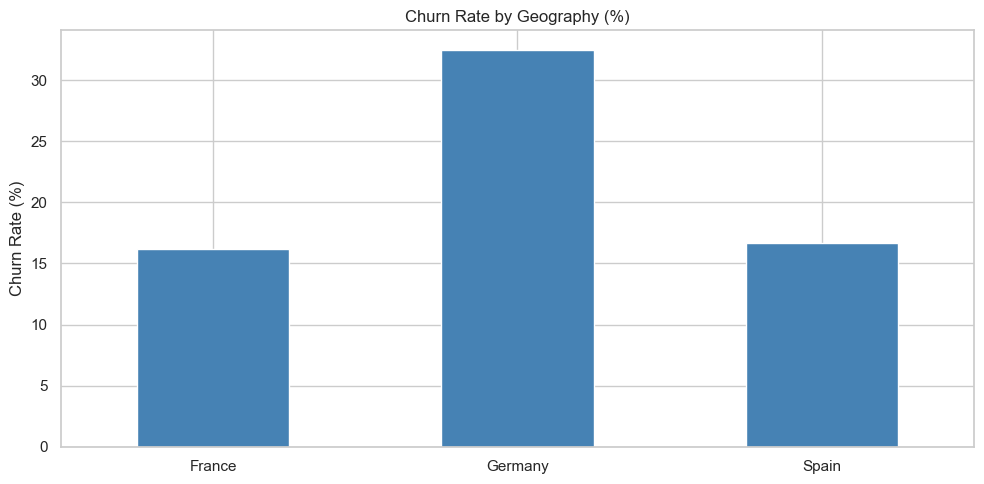

In [8]:
# --- 2.2 Churn by Geography ---
fig, ax = plt.subplots()
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Churn Rate by Geography (%)')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

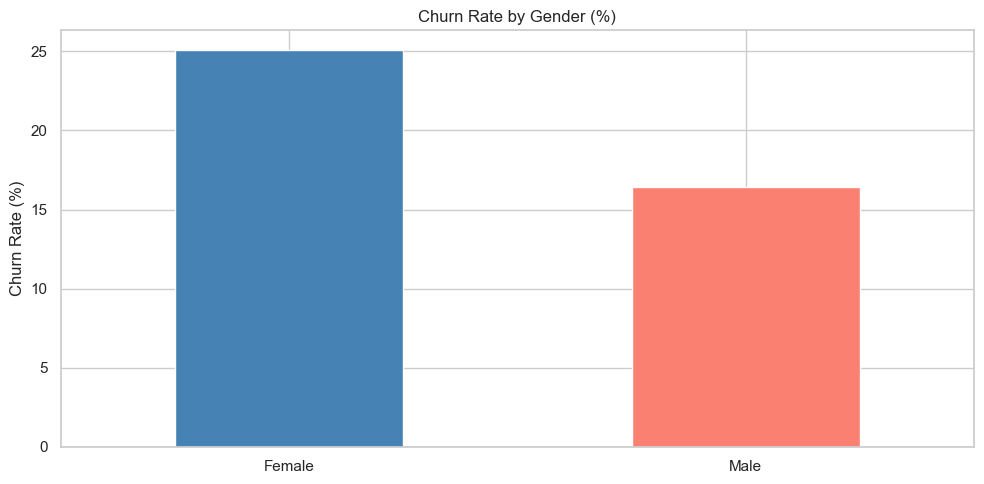

In [9]:
# --- 2.3 Churn by Gender ---
fig, ax = plt.subplots()
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
gender_churn.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white')
ax.set_title('Churn Rate by Gender (%)')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

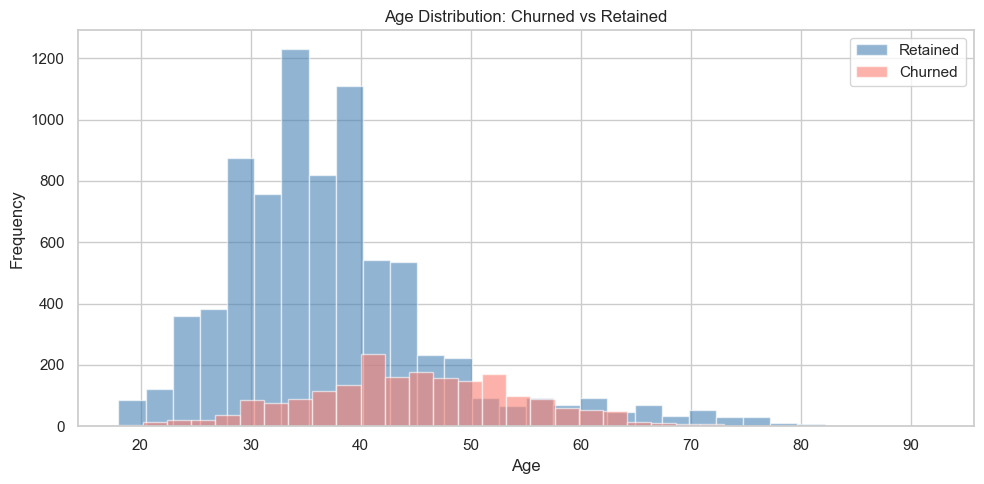

In [10]:
# --- 2.4 Age Distribution by Churn ---
fig, ax = plt.subplots()
df[df['Exited'] == 0]['Age'].plot(kind='hist', bins=30, alpha=0.6, label='Retained', ax=ax, color='steelblue')
df[df['Exited'] == 1]['Age'].plot(kind='hist', bins=30, alpha=0.6, label='Churned', ax=ax, color='salmon')
ax.set_title('Age Distribution: Churned vs Retained')
ax.set_xlabel('Age')
ax.legend()
plt.tight_layout()
plt.show()

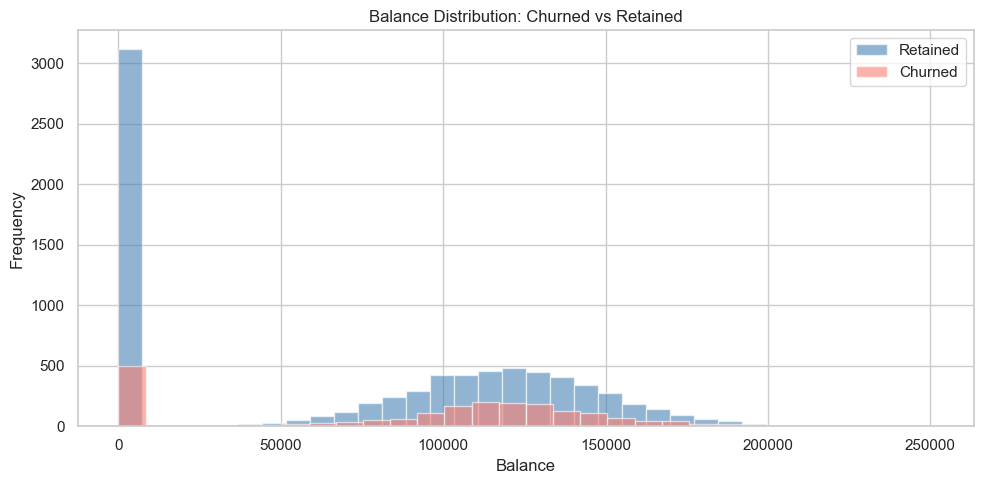

In [11]:
# --- 2.5 Balance Distribution by Churn ---
fig, ax = plt.subplots()
df[df['Exited'] == 0]['Balance'].plot(kind='hist', bins=30, alpha=0.6, label='Retained', ax=ax, color='steelblue')
df[df['Exited'] == 1]['Balance'].plot(kind='hist', bins=30, alpha=0.6, label='Churned', ax=ax, color='salmon')
ax.set_title('Balance Distribution: Churned vs Retained')
ax.set_xlabel('Balance')
ax.legend()
plt.tight_layout()
plt.show()

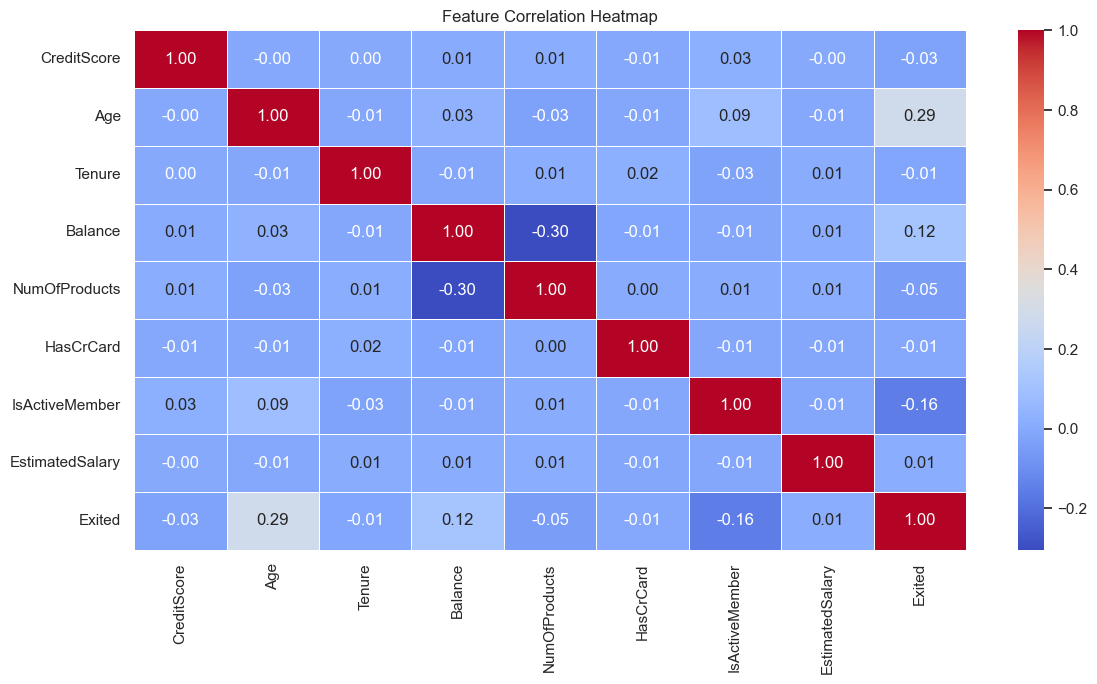

In [12]:
# --- 2.6 Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(12, 7))
numeric_df = df.select_dtypes(include=np.number).drop(columns=['RowNumber', 'CustomerId'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

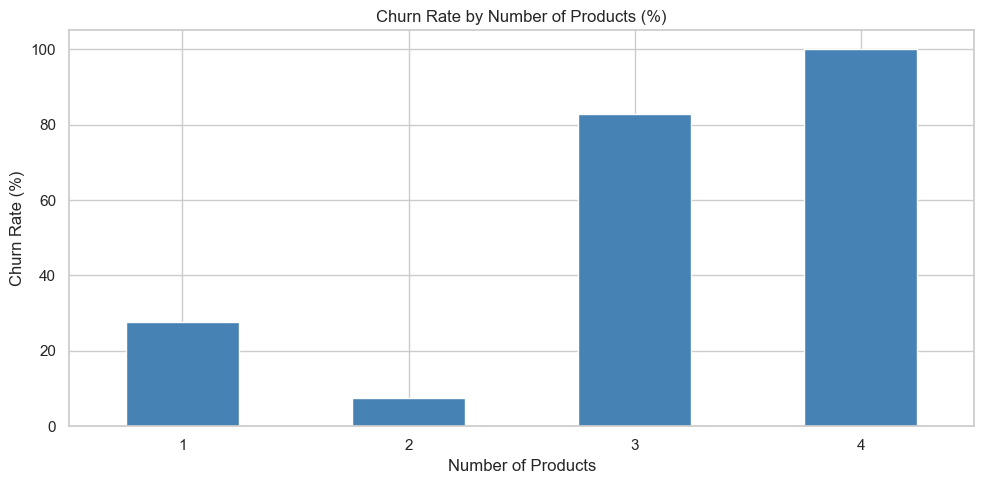

In [13]:
# --- 2.7 Churn by Number of Products ---
fig, ax = plt.subplots()
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
prod_churn.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Churn Rate by Number of Products (%)')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Number of Products')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

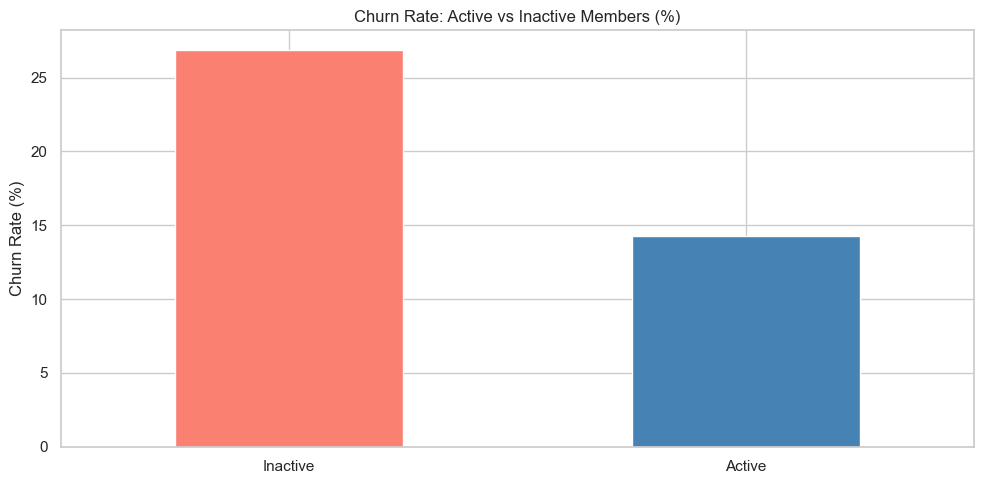

In [14]:
# --- 2.8 Active Member vs Churn ---
fig, ax = plt.subplots()
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
active_churn.index = ['Inactive', 'Active']
active_churn.plot(kind='bar', ax=ax, color=['salmon', 'steelblue'], edgecolor='white')
ax.set_title('Churn Rate: Active vs Inactive Members (%)')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [15]:
# --- 3.1 Drop irrelevant columns ---
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# --- 3.2 Encode categorical columns ---
le_gender = LabelEncoder()
df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])  # Male=1, Female=0

# One-hot encode Geography
# df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)

df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)
# Convert boolean dummy columns to int — newer XGBoost treats bool columns as categorical
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print('Columns after encoding:')
print(df_clean.columns.tolist())
df_clean.head()

Columns after encoding:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [16]:
# --- 3.3 Split features and target ---
X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

# Save feature names for deployment
feature_names = X.columns.tolist()
print('Features:', feature_names)
print('Target distribution:', y.value_counts().to_dict())

Features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
Target distribution: {0: 7963, 1: 2037}


In [17]:
# --- 3.4 Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (8000, 11), Test size: (2000, 11)


In [18]:
# --- 3.5 Handle class imbalance with SMOTE ---
# SMOTE generates synthetic samples for the minority class (churned customers)
# so the model doesn't just learn to predict "retained" every time
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE: ', pd.Series(y_train_bal).value_counts().to_dict())

Before SMOTE: {0: 6370, 1: 1630}
After SMOTE:  {1: 6370, 0: 6370}


In [19]:
# --- 3.6 Scale features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

print('Scaling done.')

Scaling done.


## 4. Model Training & Evaluation

In [20]:
# Helper function to evaluate any model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    roc = roc_auc_score(y_te, y_prob)

    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'F1 Score : {f1:.4f}')
    print(f'ROC-AUC  : {roc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Retained', 'Churned']))

    # Confusion matrix
    fig, ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Retained', 'Churned'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    return model, {'name': name, 'accuracy': acc, 'f1': f1, 'roc_auc': roc}


=== Logistic Regression ===
Accuracy : 0.7300
F1 Score : 0.4706
ROC-AUC  : 0.7433
              precision    recall  f1-score   support

    Retained       0.88      0.77      0.82      1593
     Churned       0.39      0.59      0.47       407

    accuracy                           0.73      2000
   macro avg       0.64      0.68      0.64      2000
weighted avg       0.78      0.73      0.75      2000



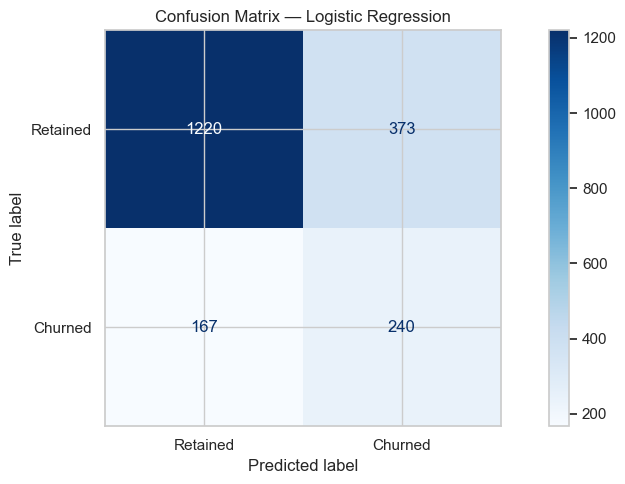

In [21]:
# --- 4.1 Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_model, lr_scores = evaluate_model(
    'Logistic Regression', lr,
    X_train_scaled, X_test_scaled, y_train_bal, y_test
)


=== Decision Tree ===
Accuracy : 0.7905
F1 Score : 0.5622
ROC-AUC  : 0.8231
              precision    recall  f1-score   support

    Retained       0.90      0.82      0.86      1593
     Churned       0.49      0.66      0.56       407

    accuracy                           0.79      2000
   macro avg       0.70      0.74      0.71      2000
weighted avg       0.82      0.79      0.80      2000



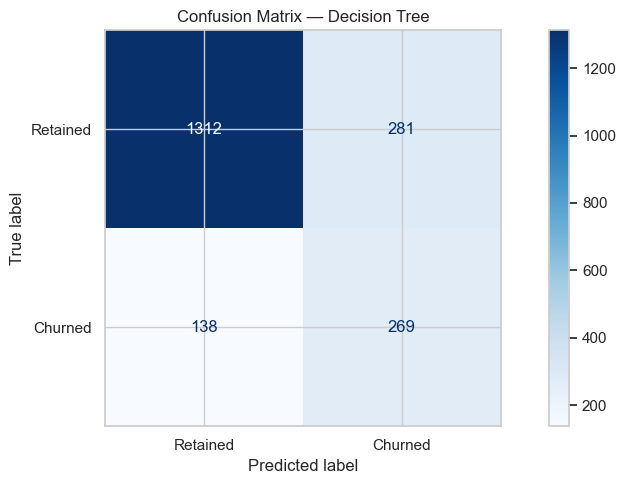

In [22]:
# --- 4.2 Decision Tree ---
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model, dt_scores = evaluate_model(
    'Decision Tree', dt,
    X_train_scaled, X_test_scaled, y_train_bal, y_test
)


=== XGBoost ===
Accuracy : 0.8075
F1 Score : 0.5811
ROC-AUC  : 0.8457
              precision    recall  f1-score   support

    Retained       0.91      0.85      0.88      1593
     Churned       0.52      0.66      0.58       407

    accuracy                           0.81      2000
   macro avg       0.71      0.75      0.73      2000
weighted avg       0.83      0.81      0.82      2000



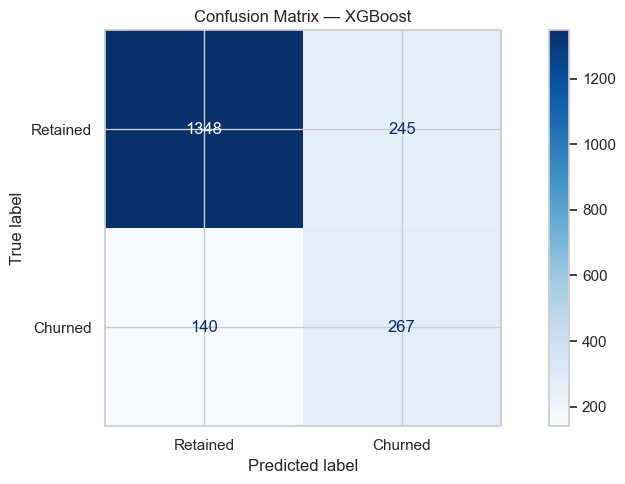

In [23]:
# --- 4.3 XGBoost ---
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model, xgb_scores = evaluate_model(
    'XGBoost', xgb,
    X_train_scaled, X_test_scaled, y_train_bal, y_test
)

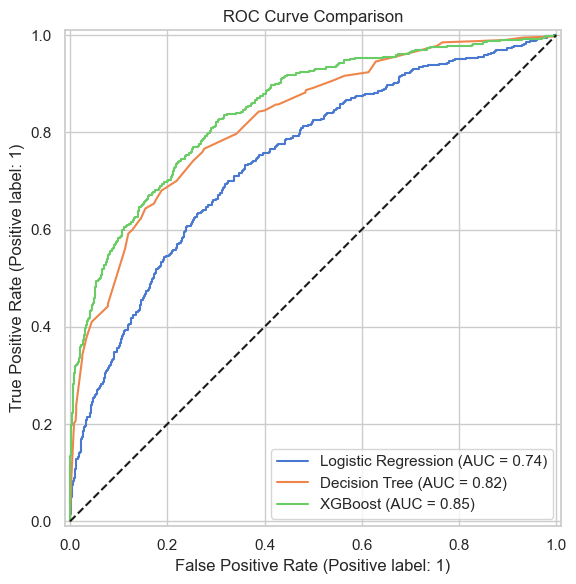

In [24]:
# --- 4.4 ROC Curve Comparison ---
fig, ax = plt.subplots(figsize=(8, 6))
for model, name in [(lr_model, 'Logistic Regression'), (dt_model, 'Decision Tree'), (xgb_model, 'XGBoost')]:
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curve Comparison')
plt.tight_layout()
plt.show()


Model Comparison:
                     accuracy      f1  roc_auc
name                                          
XGBoost                0.8075  0.5811   0.8457
Decision Tree          0.7905  0.5622   0.8231
Logistic Regression    0.7300  0.4706   0.7433


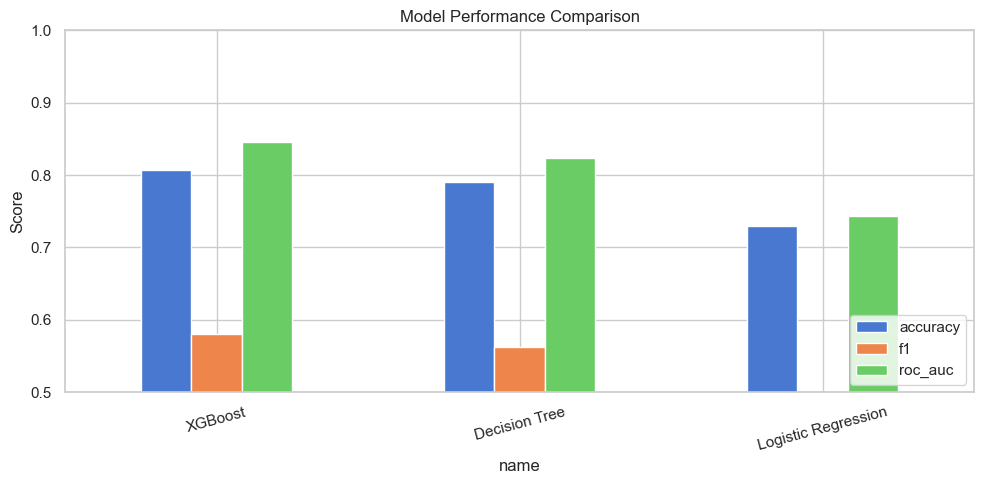

In [25]:
# --- 4.5 Model Comparison Summary ---
results = pd.DataFrame([lr_scores, dt_scores, xgb_scores])
results = results.set_index('name').sort_values('roc_auc', ascending=False)
print('\nModel Comparison:')
print(results.round(4))

fig, ax = plt.subplots()
results[['accuracy', 'f1', 'roc_auc']].plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.tick_params(axis='x', rotation=15)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 5. SHAP Explainability (XGBoost)

In [26]:
# --- 5.1 SHAP Values (computed natively via XGBoost, bypasses SHAP library bug) ---
import xgboost as xgb

dtest = xgb.DMatrix(X_test_scaled, feature_names=feature_names)
shap_contribs = xgb_model.get_booster().predict(dtest, pred_contribs=True)

# Last column is the base (expected) value; rest are per-feature SHAP values
base_value = shap_contribs[0, -1]
shap_vals_array = shap_contribs[:, :-1]

# Wrap into a shap.Explanation object so the existing plotting cells still work unchanged
shap_values = shap.Explanation(
    values=shap_vals_array,
    base_values=np.full(shap_vals_array.shape[0], base_value),
    data=X_test_scaled,
    feature_names=feature_names
)

print('SHAP values computed successfully via XGBoost native method.')

SHAP values computed successfully via XGBoost native method.


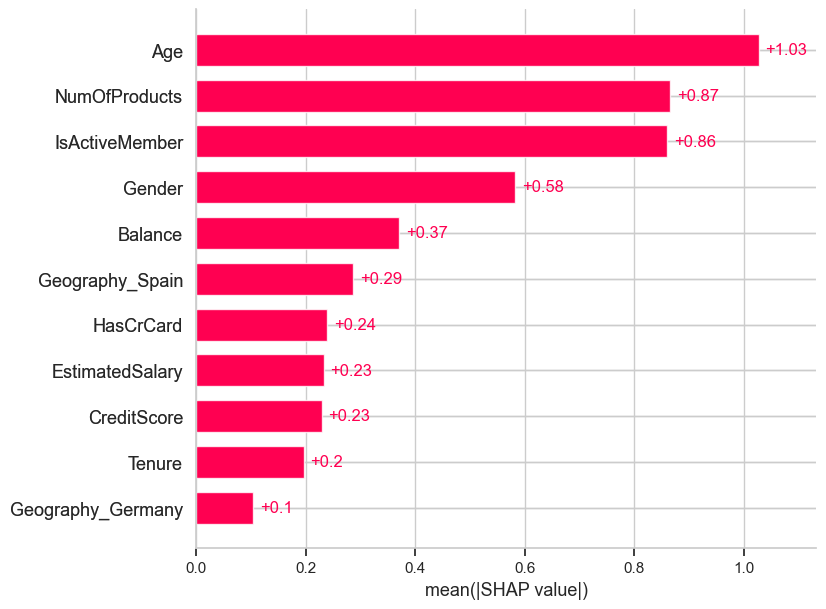

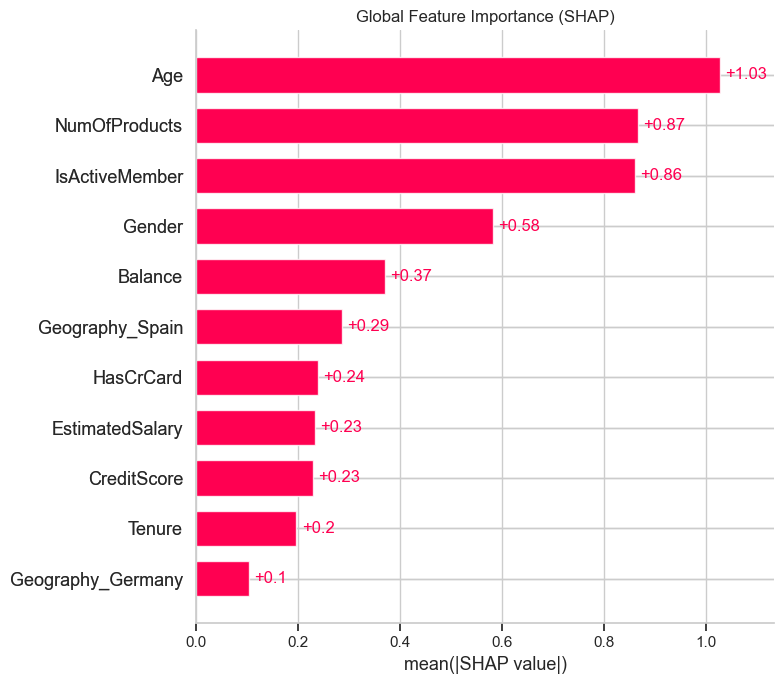

In [27]:
# --- 5.2 Global Feature Importance (Bar Plot) ---
shap.plots.bar(shap_values, max_display=12)
plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()

shap.plots.bar(shap_values, max_display=12, show=False)
plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

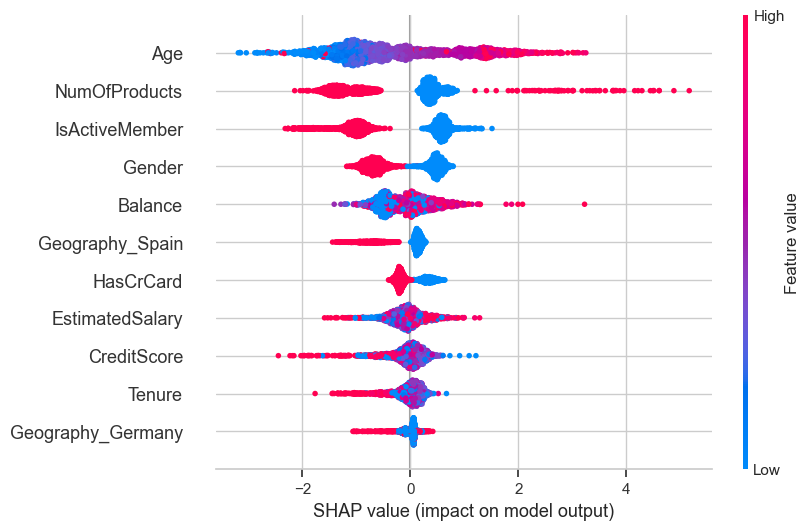

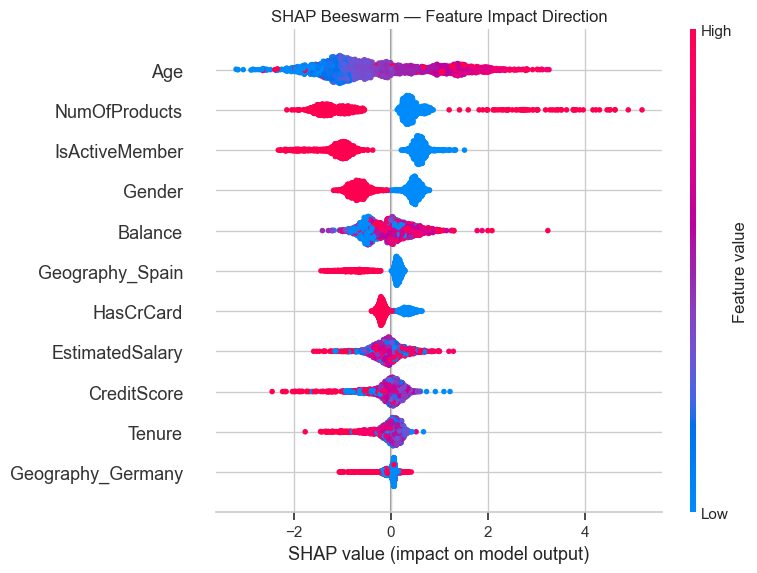

In [28]:
# --- 5.3 Beeswarm Plot (impact direction) ---
shap.plots.beeswarm(shap_values, max_display=12)
plt.title('SHAP Beeswarm — Feature Impact Direction')
plt.tight_layout()

shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction')
plt.tight_layout()
plt.show()

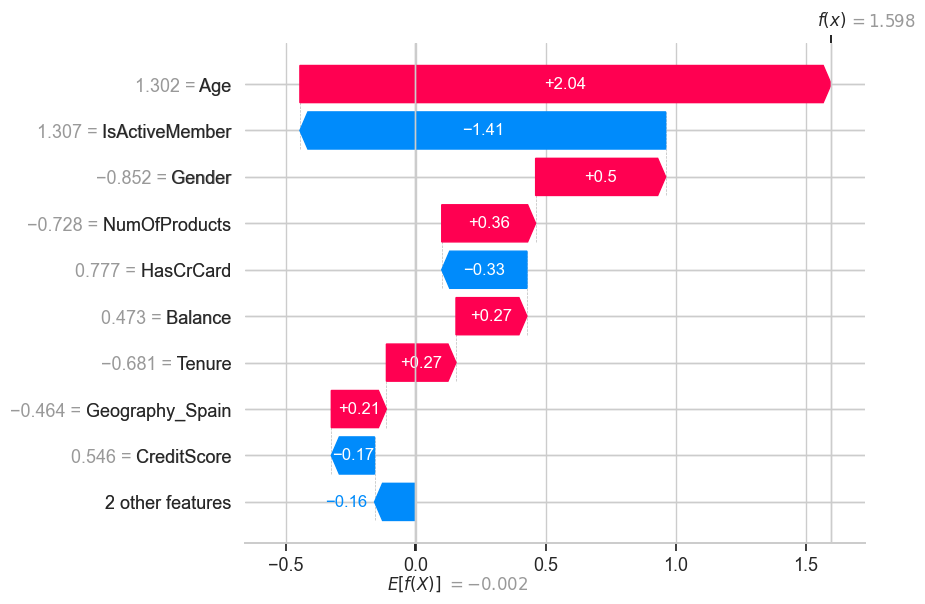

In [29]:
# --- 5.4 Individual prediction waterfall (first churned customer) ---
churned_idx = y_test[y_test == 1].index[0]
test_idx = list(y_test.index).index(churned_idx)
shap.plots.waterfall(shap_values[test_idx])

## 6. Save Model & Artifacts for Deployment

In [30]:
import os
os.makedirs('../models', exist_ok=True)

# Save XGBoost model
joblib.dump(xgb_model, '../models/xgb_model.pkl')

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

# Save feature names (needed to reconstruct input in deployment)
joblib.dump(feature_names, '../models/feature_names.pkl')

# Save SHAP explainer
# joblib.dump(explainer, '../models/shap_explainer.pkl')

print('All artifacts saved to /models:')
print(os.listdir('../models'))

All artifacts saved to /models:
['feature_names.pkl', 'scaler.pkl', 'xgb_model.pkl']


## Summary

| Model | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| Logistic Regression | 0.7300 | 0.4706 | 0.7433 |
| Decision Tree | 0.7905 | 0.5622 | 0.8231 |
| **XGBoost** | **0.8075** | **0.5811** | **0.8457** |

**Key findings from EDA:**
- Overall churn rate: 20.4%
- Germany has nearly double the churn rate of France/Spain (~32% vs ~16%)
- Customers with 3-4 products churn far more (83-100%) than those with 1-2 products
- Inactive members churn at ~27% vs ~14% for active members
- Female customers churn more than male (25% vs 16%)
- Churn rises steadily with customer age

**Top SHAP features:**
- Age, Number of Products, and Active Membership status are the strongest churn drivers
- Gender and Balance follow as secondary contributors
- Geography (Germany specifically) has a smaller but consistent effect